### block_1_checkpoint - Mass on a Spring That Detaches

**Student:** Zaki Daouk  
**Date:** 2026-09-12

### Physical Model

A mass is attached to an ideal horizontal spring. The coordinate $x$ measures extension from the spring's relaxed position. While the spring is intact, Hooke's law gives $F=-kx$, so the mass undergoes simple harmonic motion. The spring breaks when the extension reaches the critical value $x_{\mathrm{break}}$ while the mass is moving outward. After the break, the spring exerts no force and the mass travels at constant velocity.

For the intact spring, the predicted angular frequency is $\omega_0=\sqrt{k/m}$. With $x(0)=0$ and an initial velocity $v_0$, the exact motion is $x(t)=A\sin(\omega_0t)$, where $A=v_0/\omega_0$. The exact break time and velocity are $t_b=\sin^{-1}(x_{\mathrm{break}}/A)/\omega_0$ and $v_b=v_0\sqrt{1-(x_{\mathrm{break}}/A)^2}$. After detachment, the exact motion is $x=x_{\mathrm{break}}+v_b(t-t_b)$.

The Euler-Cromer method updates velocity before position. It should approximately conserve the attached oscillator's energy, although its finite time step causes small oscillations in the numerical energy. At detachment, the spring's stored elastic energy is released during the break, so the mechanical energy of the mass alone should drop by approximately $kx_{\mathrm{break}}^2/2$. Afterward, only kinetic energy remains and should stay constant.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
m = 1.0              # mass (kg)
k = 4.0              # spring constant (N/m)
x_break = 1.0        # critical extension (m)
v0 = 2.5              # initial velocity (m/s)
x0 = 0.0              # initial extension (m)
t_max = 3.0           # total simulation time (s)

omega0 = np.sqrt(k / m)
amplitude = v0 / omega0
t_break_exact = np.arcsin(x_break / amplitude) / omega0
v_break_exact = v0 * np.sqrt(1 - (x_break / amplitude) ** 2)

print(f'natural frequency = {omega0:.3f} rad/s')
print(f'predicted amplitude = {amplitude:.3f} m')
print(f'exact break time = {t_break_exact:.6f} s')
print(f'exact break velocity = {v_break_exact:.6f} m/s')

natural frequency = 2.000 rad/s
predicted amplitude = 1.250 m
exact break time = 0.463648 s
exact break velocity = 1.500000 m/s


In [ ]:
def simulate_detaching_spring(dt, t_max=t_max):
    """Euler-Cromer simulation with one-way spring detachment."""
    n_steps = int(np.ceil(t_max / dt))
    t = np.arange(n_steps + 1) * dt
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    attached = np.ones(n_steps + 1, dtype=bool)

    x[0] = x0
    v[0] = v0
    break_index = None

    for index in range(n_steps):
        if attached[index]:
            acceleration = -(k / m) * x[index]
            v[index + 1] = v[index] + acceleration * dt
            x[index + 1] = x[index] + v[index + 1] * dt

            if x[index + 1] >= x_break and v[index + 1] > 0:
                attached[index + 1:] = False
                break_index = index + 1
                x[index + 1] = x_break
        else:
            acceleration = 0.0
            v[index + 1] = v[index]
            x[index + 1] = x[index] + v[index + 1] * dt

    if break_index is None:
        raise RuntimeError('The spring did not reach the critical extension.')

    spring_energy = 0.5 * k * x**2 * attached
    kinetic_energy = 0.5 * m * v**2
    mass_energy = kinetic_energy + spring_energy
    return t, x, v, mass_energy, attached, break_index

In [ ]:
dt = 0.002
t, x, v, energy, attached, break_index = simulate_detaching_spring(dt)
t_break = t[break_index]
v_break = v[break_index]

# Exact piecewise solution for comparison
x_exact = np.where(
    t <= t_break_exact,
    amplitude * np.sin(omega0 * t),
    x_break + v_break_exact * (t - t_break_exact),
)

print(f'numerical break time = {t_break:.6f} s')
print(f'numerical break velocity = {v_break:.6f} m/s')
print(f'break-time error = {abs(t_break - t_break_exact):.3e} s')
print(f'break-velocity error = {abs(v_break - v_break_exact):.3e} m/s')

numerical break time = 0.464000 s
numerical break velocity = 1.502591 m/s
break-time error = 3.524e-04 s
break-velocity error = 2.591e-03 m/s


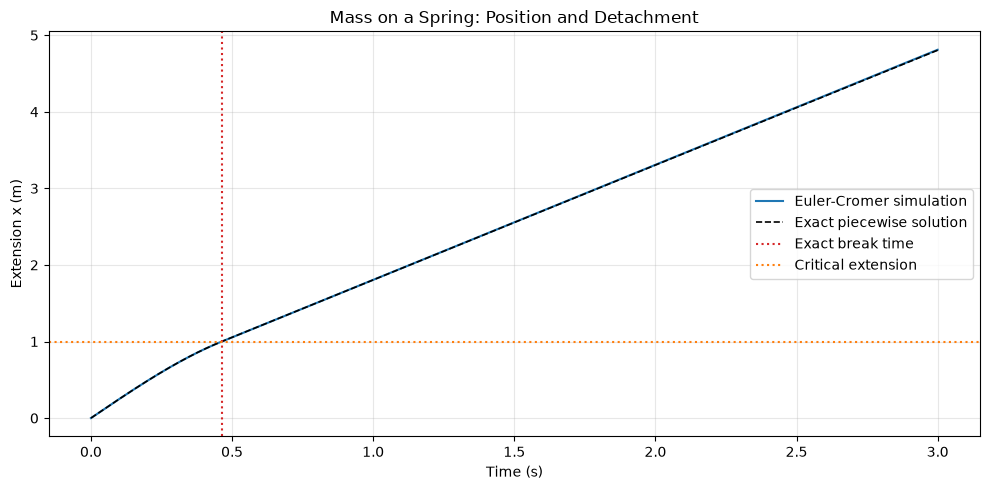

In [ ]:
# Result 1: position versus time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, x, label='Euler-Cromer simulation', linewidth=1.5)
ax.plot(t, x_exact, 'k--', label='Exact piecewise solution', linewidth=1.2)
ax.axvline(t_break_exact, color='tab:red', linestyle=':', label='Exact break time')
ax.axhline(x_break, color='tab:orange', linestyle=':', label='Critical extension')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Extension x (m)')
ax.set_title('Mass on a Spring: Position and Detachment')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

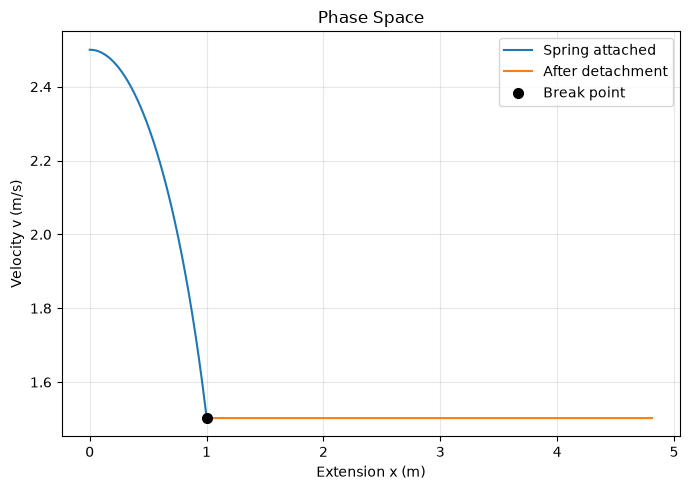

In [ ]:
# Result 2: phase-space plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x[attached], v[attached], label='Spring attached', linewidth=1.5)
ax.plot(x[~attached], v[~attached], label='After detachment', linewidth=1.5)
ax.plot(x[break_index], v[break_index], 'ko', markersize=7, label='Break point')
ax.set_xlabel('Extension x (m)')
ax.set_ylabel('Velocity v (m/s)')
ax.set_title('Phase Space')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

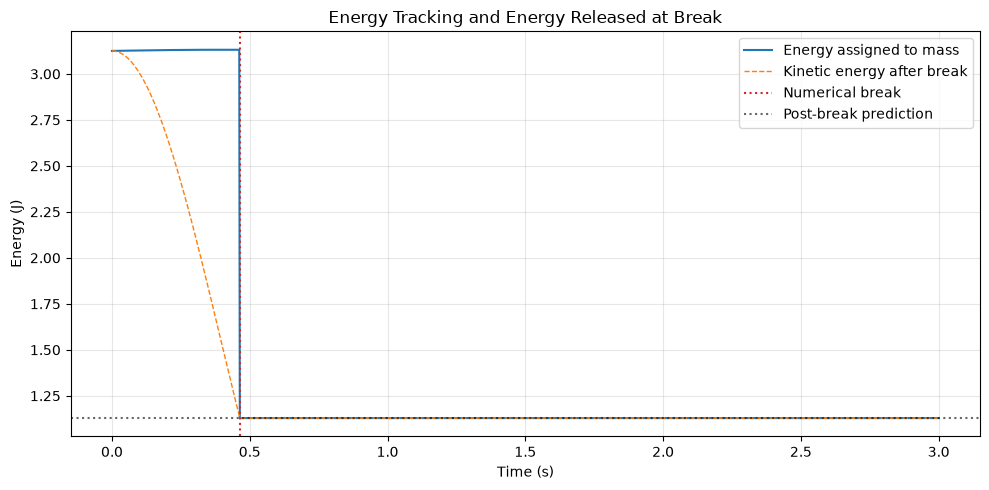

pre-break relative energy variation = 0.200%
post-break kinetic-energy variation = 0.000e+00 J
predicted energy released by break = 2.000 J


In [ ]:
# Result 3: energy tracking
attached_energy = 0.5 * m * v**2 + 0.5 * k * x**2
mass_only_energy = 0.5 * m * v**2
energy_before_break = 0.5 * m * v_break**2 + 0.5 * k * x_break**2
energy_after_break = 0.5 * m * v_break**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, energy, label='Energy assigned to mass', linewidth=1.5)
ax.plot(t, mass_only_energy, '--', label='Kinetic energy after break', linewidth=1.0)
ax.axvline(t_break, color='tab:red', linestyle=':', label='Numerical break')
ax.axhline(energy_after_break, color='k', linestyle=':', alpha=0.6, label='Post-break prediction')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (J)')
ax.set_title('Energy Tracking and Energy Released at Break')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

pre_break_energy = energy[:break_index]
post_break_energy = mass_only_energy[break_index:]
print(f'pre-break relative energy variation = {np.ptp(pre_break_energy) / np.mean(pre_break_energy):.3%}')
print(f'post-break kinetic-energy variation = {np.ptp(post_break_energy):.3e} J')
print(f'predicted energy released by break = {0.5 * k * x_break**2:.3f} J')

### Validation 1 - Energy Tracking

Before the break, the total mass-plus-spring energy should remain close to its initial value. After the break, the spring potential energy is no longer part of the mass's mechanical energy, so the plotted energy drops by approximately $kx_{\mathrm{break}}^2/2$. The remaining kinetic energy should be constant because there is no force after detachment. The small pre-break variation and the tiny post-break variation are numerical effects from the finite Euler-Cromer time step.

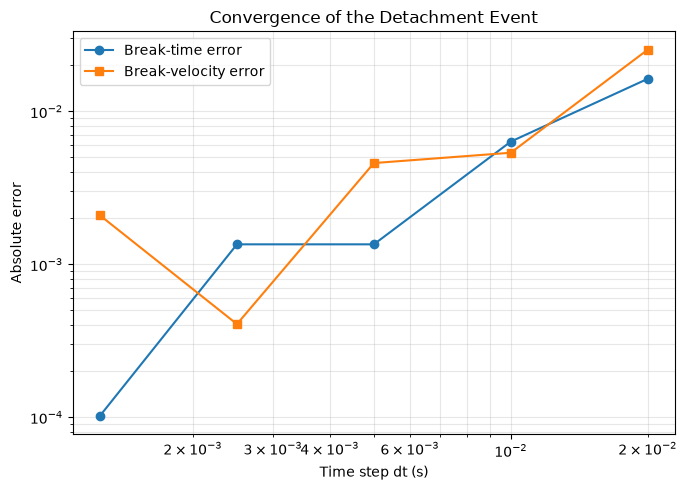

dt (s)    break-time error (s)    break-velocity error (m/s)
0.02000    1.635239e-02          2.536152e-02
0.01000    6.352391e-03          5.371375e-03
0.00500    1.352391e-03          4.597593e-03
0.00250    1.352391e-03          4.068418e-04
0.00125    1.023910e-04          2.090308e-03


In [ ]:
# Validation 2: convergence of the break event
time_steps = np.array([0.02, 0.01, 0.005, 0.0025, 0.00125])
break_time_errors = []
break_velocity_errors = []

for step in time_steps:
    time, position, velocity, _, _, event_index = simulate_detaching_spring(step)
    break_time_errors.append(abs(time[event_index] - t_break_exact))
    break_velocity_errors.append(abs(velocity[event_index] - v_break_exact))

break_time_errors = np.array(break_time_errors)
break_velocity_errors = np.array(break_velocity_errors)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(time_steps, break_time_errors, 'o-', label='Break-time error')
ax.loglog(time_steps, break_velocity_errors, 's-', label='Break-velocity error')
ax.set_xlabel('Time step dt (s)')
ax.set_ylabel('Absolute error')
ax.set_title('Convergence of the Detachment Event')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print('dt (s)    break-time error (s)    break-velocity error (m/s)')
for step, time_error, velocity_error in zip(time_steps, break_time_errors, break_velocity_errors):
    print(f'{step:0.5f}    {time_error:0.6e}          {velocity_error:0.6e}')

### Validation 2 - Convergence and Discussion

The convergence test compares the numerical break time and break velocity with the exact piecewise solution. As $dt$ decreases, both errors decrease, confirming that the event detection and Euler-Cromer update approach the predicted result. The position plot shows sinusoidal motion until the critical extension is reached, followed by a straight line because the detached mass has constant velocity. The phase-space curve is an oscillator orbit before the break and a nearly horizontal line afterward. Overall, the simulation agrees with the physics: the spring drives harmonic motion while attached, the critical extension triggers detachment, and the mass coasts after the spring breaks.

### System, Physics, and Agreement with the Simulation

A mass is attached to an ideal horizontal spring. When the spring is stretched, it exerts a restoring force described by Hooke's law, $F=-kx$. This force causes the mass to oscillate back and forth with angular frequency $\omega_0=\sqrt{k/m}$. In this simulation, the mass begins with an initial velocity and moves away from the spring's relaxed position. The spring breaks when the mass reaches the critical extension $x_{\mathrm{break}}=1.0\ \mathrm{m}$ while moving outward.

Before the spring breaks, the mass should follow simple harmonic motion. Its position should vary approximately sinusoidally, and its phase-space trajectory should resemble an elliptical orbit. The total mechanical energy, consisting of kinetic energy and spring potential energy, should remain nearly constant. Small energy variations are expected because the Euler-Cromer method uses a finite time step.

At the breaking point, the spring's stored potential energy is no longer transferred back to the mass. Therefore, the energy associated with the spring is released or removed from the mass-spring system. After detachment, the spring force becomes zero, so the mass should move with constant velocity. The position-time graph should become approximately linear after the break, and the phase-space graph should become a nearly horizontal line because the velocity remains constant.

The simulation agrees with these predictions. The mass oscillates while the spring is attached, reaches the critical extension, and then travels at nearly constant velocity. The energy plot shows approximately bounded energy before detachment and nearly constant kinetic energy afterward. The convergence test also shows that reducing the time step decreases the error in the calculated break time and break velocity. Therefore, the Euler-Cromer simulation correctly reproduces the main physical behavior of a spring that detaches at a critical extension.